# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [5]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.isnull().sum()
df.isnull().values.any()
#df.columns

np.False_

### Double check some datatypes, and for nulls and duplicates:

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [14]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [8]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [9]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [10]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'postal_code'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [18]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [11]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [18]:
query2 = """SELECT 
c.customer_id
,c.customer_name
,od.sales
FROM orders o 
join customers c on c.customer_id = o.customer_id
join order_details od on o.order_id = od.order_id
group by c.customer_id, c.customer_name, od.sales
order by od.sales desc
limit 10;
"""
result2 = pd.read_sql(query2, conn)
result2

,customer_id,customer_name,Sales
0,SM-20320,Sean Miller,22638.480
1,TC-20980,Tamara Chand,17499.950
2,RB-19360,Raymond Buch,13999.960
3,TA-21385,Tom Ashbrook,11199.968
4,HL-15040,Hunter Lopez,10499.970
5,AB-10105,Adrian Barton,9892.740
6,SC-20095,Sanjit Chand,9449.950
7,BS-11365,Bill Shonely,9099.930
8,SE-20110,Sanjit Engle,8749.950
9,CC-12370,Christopher Conant,8399.976


### Which product categories and subcategories are the most profitable overall?

In [23]:
query3 = """ select
od.product_id
,p.category
,p.subcategory
,od.Profit
from order_details od 
join products p on od.product_id = p.product_id
order by od.profit desc
 """
result3 = pd.read_sql(query3, conn)
result3

,product_id,category,subcategory,Profit
0,TEC-CO-10004722,Technology,Copiers,8399.9760
1,TEC-CO-10004722,Technology,Copiers,6719.9808
2,TEC-CO-10004722,Technology,Copiers,5039.9856
3,OFF-BI-10000545,Office Supplies,Binders,4946.3700
4,OFF-BI-10001120,Office Supplies,Binders,4630.4755
...,...,...,...,...
10326,OFF-BI-10001120,Office Supplies,Binders,-2929.4845
10327,TEC-MA-10000822,Technology,Machines,-3399.9800
10328,OFF-BI-10004995,Office Supplies,Binders,-3701.8928
10329,TEC-MA-10004125,Technology,Machines,-3839.9904


### What is the average discount given per category?

In [24]:
query4 = """ select
p.category
,AVG(od.Discount)

from order_details od 
join products p on od.product_id = p.product_id
group by p.category
 """
result4 = pd.read_sql(query4, conn)
result4

,category,AVG(od.Discount)
0,Furniture,0.172514
1,Office Supplies,0.157000
2,Technology,0.132970


### Which states or regions contribute the most to total sales?

In [53]:
query5 = """ select
    c.region,
    SUM(od.Sales) as Sales
from orders o
join order_details od on o.order_id = od.order_id
join customers c on o.customer_id = c.customer_id
group by c.region
 """
result5 = pd.read_sql(query5, conn)
result5

,region,Sales
0,Central,3.853692e+06
1,East,4.522990e+06
2,South,2.706438e+06
3,West,5.306522e+06


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [ ]:
query6 = """ 
select
order_id
,order_date
,ship_date
,(ship_date - order_date) as date_diff
from orders o
where date_diff > 3
"""
result6 = pd.read_sql(query6, conn)
result6

,order_id,order_date,ship_date,date_diff
0,CA-2013-138688,13-06-2013,17-06-2013,4
1,US-2012-108966,11-10-2012,18-10-2012,7
2,CA-2011-115812,09-06-2011,14-06-2011,5
3,CA-2014-114412,16-04-2014,21-04-2014,5
4,CA-2013-161389,06-12-2013,11-12-2013,5
...,...,...,...,...
2861,US-2013-103674,07-12-2013,11-12-2013,4
2862,US-2013-157728,23-09-2013,29-09-2013,6
2863,CA-2012-100251,17-05-2012,23-05-2012,6
2864,CA-2014-163629,18-11-2014,22-11-2014,4


### Which month or year had the highest total sales?

In [36]:
query7 = """ 
select
o.order_date
,strftime('%m', o.order_date) as month
,SUM(od.sales) as sales
from orders o
join order_details od on o.order_id = od.order_id
order by month
 """
result7 = pd.read_sql(query7, conn)
result7

,order_date,month,sales
0,09-11-2013,None,2.297201e+06


### What are the most frequently ordered products?

In [38]:
query8 = """ 
select
od.product_id
,p.product_name
,quantity
from orders o
join order_details od on o.order_id = od.order_id
join products p on od.product_id = p.product_id
order by quantity desc
 """
result8 = pd.read_sql(query8, conn)
result8

,product_id,product_name,Quantity
0,OFF-FA-10000621,"OIC Colored Binder Clips, Assorted Sizes",14
1,FUR-FU-10001706,Longer-Life Soft White Bulbs,14
2,OFF-PA-10004530,Personal Creations Ink Jet Cards and Labels,14
3,OFF-ST-10001511,Space Solutions Commercial Steel Shelving,14
4,FUR-CH-10002304,"Global Stack Chair without Arms, Black",14
...,...,...,...
10326,FUR-FU-10002671,Electrix 20W Halogen Replacement Bulb for Zoom...,1
10327,OFF-PA-10000349,Staples,1
10328,FUR-TA-10001039,KI Adjustable-Height Table,1
10329,TEC-AC-10003399,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,1


### Which customers placed more than 5 orders total?

In [42]:
query9 = """ 
select*
from (select
o.customer_id
,count(o.order_id) as order_count
from orders o 
group by o.customer_id) as t

where t.order_count>5
 
 """
result9 = pd.read_sql(query9, conn)
result9

,customer_id,order_count
0,AA-10375,9
1,AA-10645,6
2,AB-10060,8
3,AB-10105,10
4,AB-10165,8
...,...,...
459,VW-21775,10
460,WB-21850,11
461,XP-21865,11
462,YS-21880,8


### What’s the profit margin (profit ÷ sales) by category or segment?

In [43]:
query10 = """ 

select

p.category
,(od.profit/od.sales) as profit_margin

from order_details od
join products p on od.product_id = p.product_id
group by p.category
 """
result10 = pd.read_sql(query10, conn)
result10

,category,profit_margin
0,Furniture,0.16
1,Office Supplies,0.47
2,Technology,0.10


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

In [ ]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


Text(0, 0.5, 'Profit Margin')

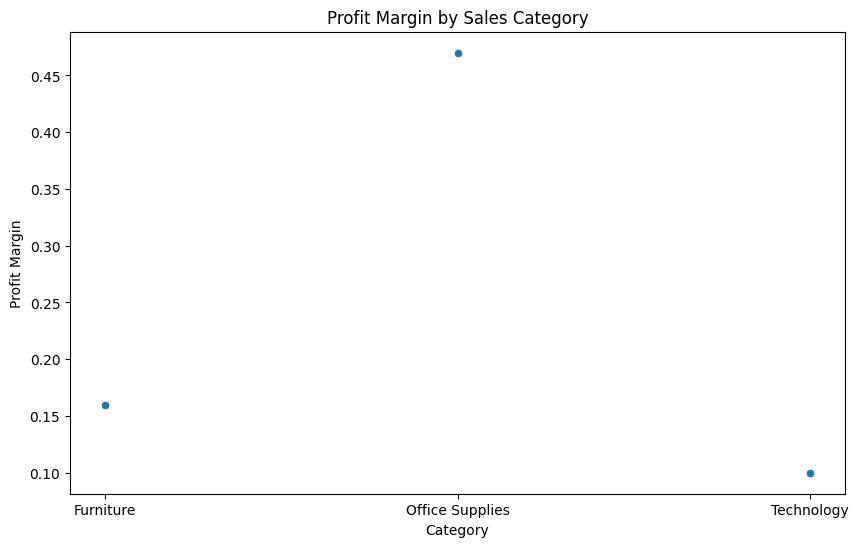

In [45]:
# visualization one code here

plt.figure(figsize=(10,6))
sns.scatterplot(result10, x='category', y='profit_margin')
plt.title('Profit Margin by Sales Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin')

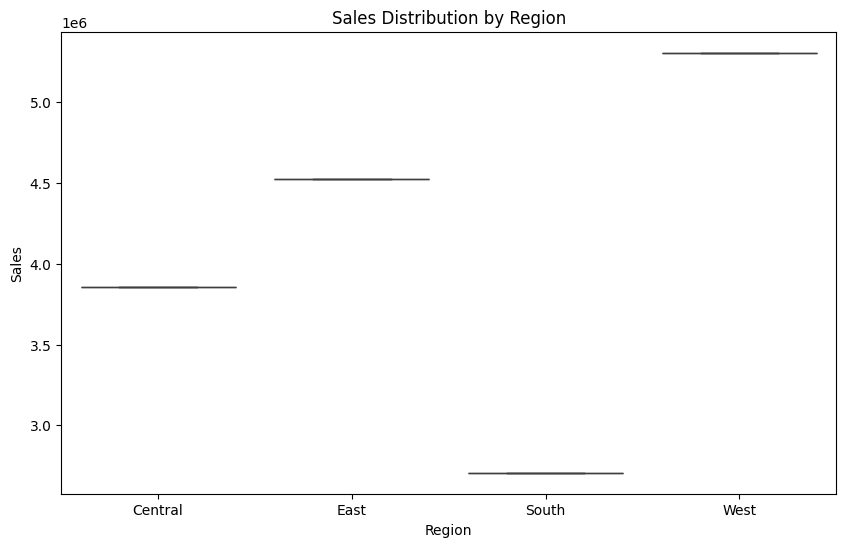

In [56]:
# visualization two code here
plt.figure(figsize=(10,6))
sns.boxplot(x='region',y='Sales',data=result5)
plt.title("Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()


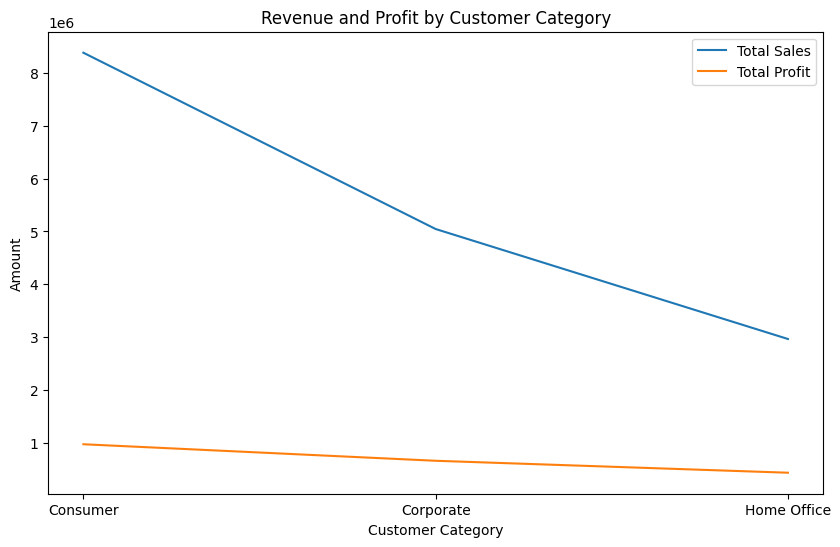

In [62]:
# visualization three code here
plt.figure(figsize=(10,6))
sns.lineplot(data=result1,x='customer_category',y='total_sales',label='Total Sales')
sns.lineplot(data=result1,x='customer_category',y='total_profit',label='Total Profit')
plt.title("Revenue and Profit by Customer Category")
plt.xlabel("Customer Category")
plt.ylabel("Amount")
plt.legend()

plt.show()


C:\Users\Eric\AppData\Local\Temp\ipykernel_19240\4052633236.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(result2, x='customer_name', y='Sales', palette=colors, legend=False)
C:\Users\Eric\AppData\Local\Temp\ipykernel_19240\4052633236.py:5: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(result2, x='customer_name', y='Sales', palette=colors, legend=False)


Text(0, 0.5, 'Total Sales ($USD)')

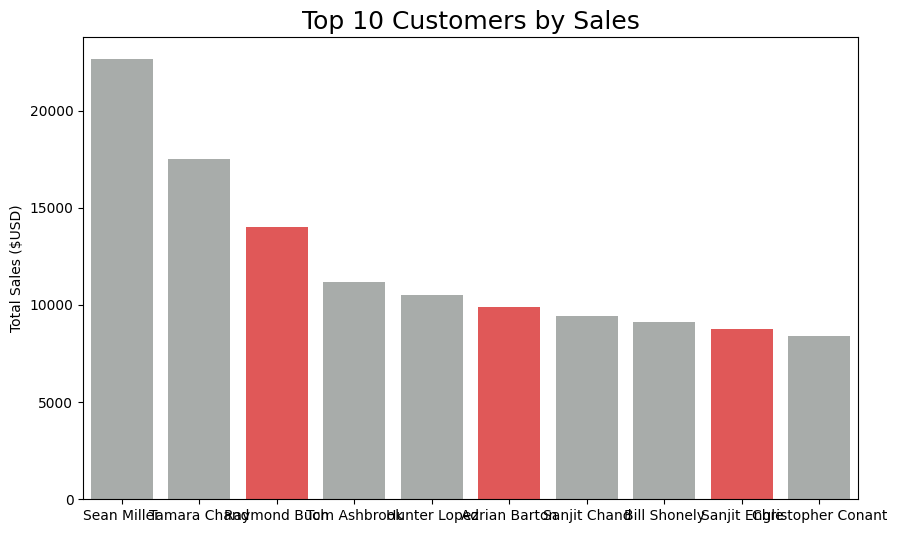

In [64]:
# visualization four code here

plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result2, x='customer_name', y='Sales', palette=colors, legend=False)
plt.title('Top 10 Customers by Sales',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')
